In [22]:
from pathlib import Path

import numpy as np
import matplotlib.pyplot as plt

from astropy.io import fits
from astropy.visualization import ImageNormalize, AsinhStretch, PercentileInterval

from photutils.background import Background2D, MedianBackground
from photutils.segmentation import detect_sources, SourceCatalog

print("JWST image environment ready")

JWST image environment ready


In [1]:
PROJECT_ROOT = Path.cwd()
if PROJECT_ROOT.name == "notebooks":
    PROJECT_ROOT = PROJECT_ROOT.parent

DATA_DIR = PROJECT_ROOT / "data"
OUTPUT_DIR = PROJECT_ROOT / "output"
OUTPUT_DIR.mkdir(parents=True, exist_ok=True)

filename = DATA_DIR / "jades_f200w.fits"

hdul = fits.open(filename, memmap=True)

hdul.info()


Filename: D:\AST\01_JWST_Image_Processing\data\jades_f200w.fits
No.    Name      Ver    Type      Cards   Dimensions   Format
  0  PRIMARY       1 PrimaryHDU     442   ()      
  1  SCI           1 ImageHDU        83   (25000, 27700)   float32   
  2  ERR           1 ImageHDU        83   (25000, 27700)   float32   
  3  EXP           1 ImageHDU        83   (25000, 27700)   float32   
  4  WHT           1 ImageHDU        83   (25000, 27700)   float32   


In [2]:
sci = hdul["SCI"].data

print(sci.shape)
print(sci.dtype)

(27700, 25000)
>f4


In [3]:
ny, nx = sci.shape

print("Full image size:", nx, ny)

cx = nx // 2
cy = ny // 2

size = 1500

cutout = sci[
    cy-size:cy+size,
    cx-size:cx+size
].copy()

print("Cutout shape:", cutout.shape)

Full image size: 25000 27700
Cutout shape: (3000, 3000)


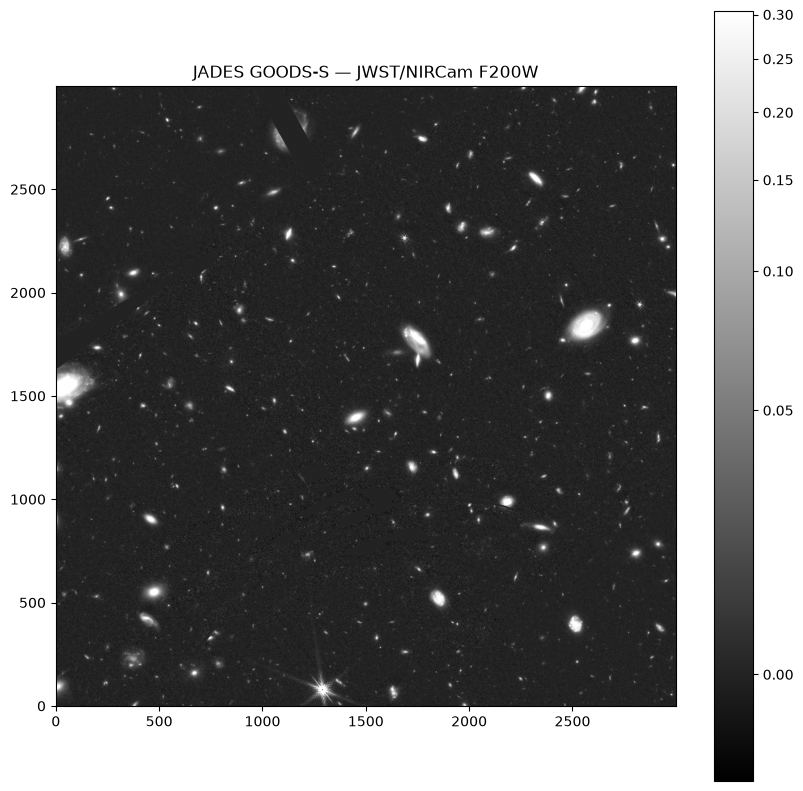

In [4]:
interval = PercentileInterval(99.5)
vmin, vmax = interval.get_limits(cutout)

norm = ImageNormalize(
    vmin=vmin,
    vmax=vmax,
    stretch=AsinhStretch()
)

plt.figure(figsize=(10, 10))
plt.imshow(cutout, origin="lower", cmap="gray", norm=norm)
plt.colorbar()
plt.title("JADES GOODS-S — JWST/NIRCam F200W")
plt.show()

In [5]:
fits.writeto(
    OUTPUT_DIR / "jades_f200w_cutout.fits",
    cutout,
    overwrite=True
)

plt.figure(figsize=(10, 10))
plt.imshow(cutout, origin="lower", cmap="gray", norm=norm)
plt.axis("off")
plt.tight_layout()

plt.savefig(
    OUTPUT_DIR / "jades_f200w_cutout.png",
    dpi=200,
    bbox_inches="tight"
)

In [9]:
bkg_estimator = MedianBackground()

bkg = Background2D(
    cutout,
    box_size=(64, 64),
    filter_size=(3, 3),
    bkg_estimator=bkg_estimator
)

print("Median background:", np.nanmedian(bkg.background))
print("Median background RMS:", np.nanmedian(bkg.background_rms))

Median background: 0.00020736025
Median background RMS: 0.0044431738


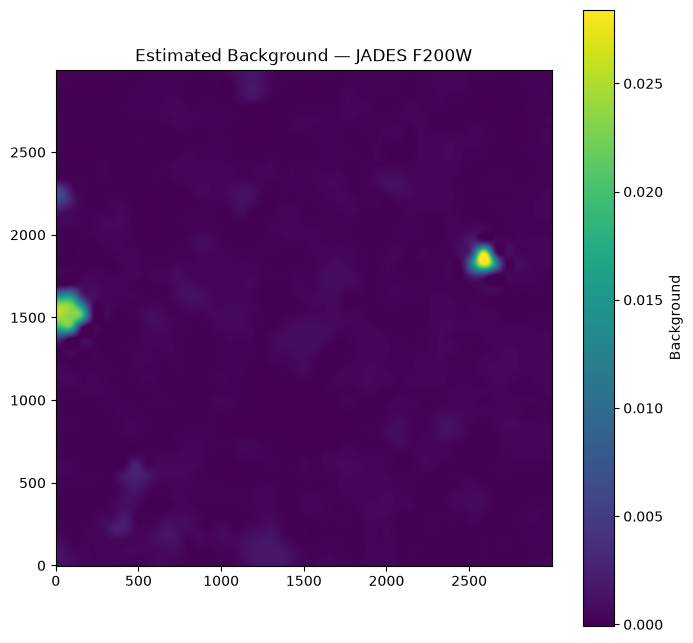

In [10]:
plt.figure(figsize=(8, 8))

plt.imshow(
    bkg.background,
    origin="lower"
)

plt.colorbar(label="Background")
plt.title("Estimated Background — JADES F200W")

plt.show()

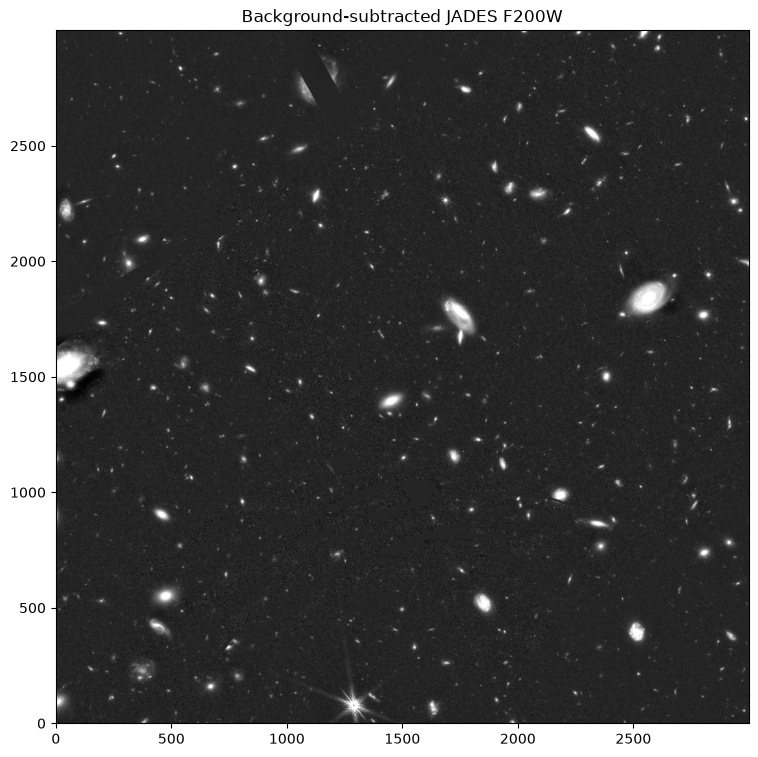

In [12]:
data_sub = cutout - bkg.background

interval = PercentileInterval(99.5)
vmin, vmax = interval.get_limits(data_sub)

norm = ImageNormalize(
    vmin=vmin,
    vmax=vmax,
    stretch=AsinhStretch()
)

plt.figure(figsize=(9, 9))
plt.imshow(
    data_sub,
    origin="lower",
    cmap="gray",
    norm=norm
)

plt.title("Background-subtracted JADES F200W")
plt.show()

In [15]:
threshold = 5.0 * bkg.background_rms #1.5σ 2σ 3σ 5σ

segm = detect_sources(
    data_sub,
    threshold,
    10
)

print(segm)

<photutils.segmentation.core.SegmentationImage>
shape: (3000, 3000)
n_labels: 775
labels: [  1   2   3   4   5 ... 771 772 773 774 775]


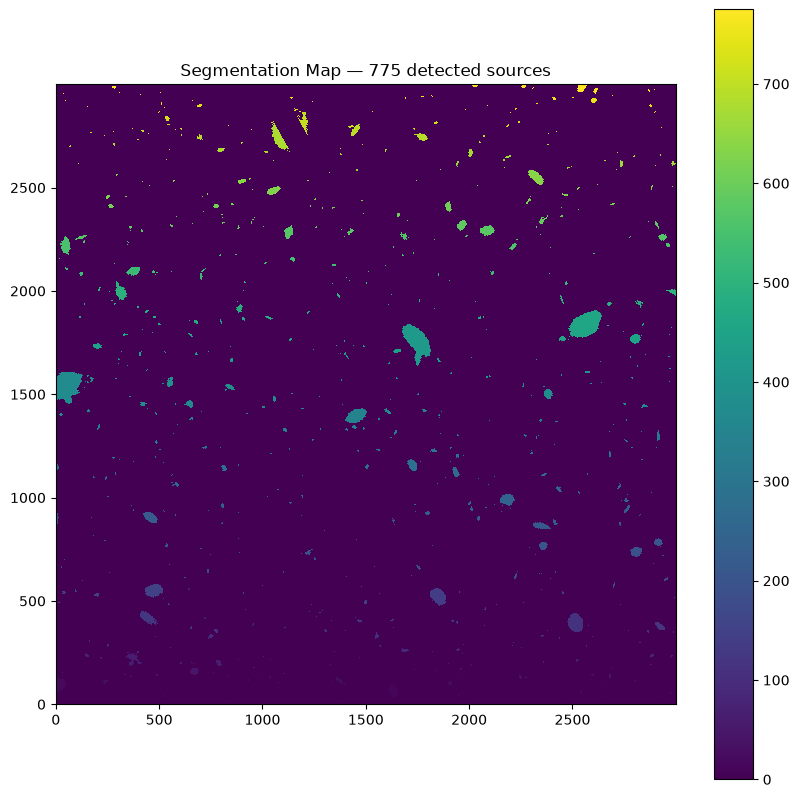

In [16]:
plt.figure(figsize=(10, 10))

plt.imshow(
    segm.data,
    origin="lower",
    interpolation="nearest"
)

plt.colorbar()
plt.title(f"Segmentation Map — {segm.nlabels} detected sources")

plt.show()

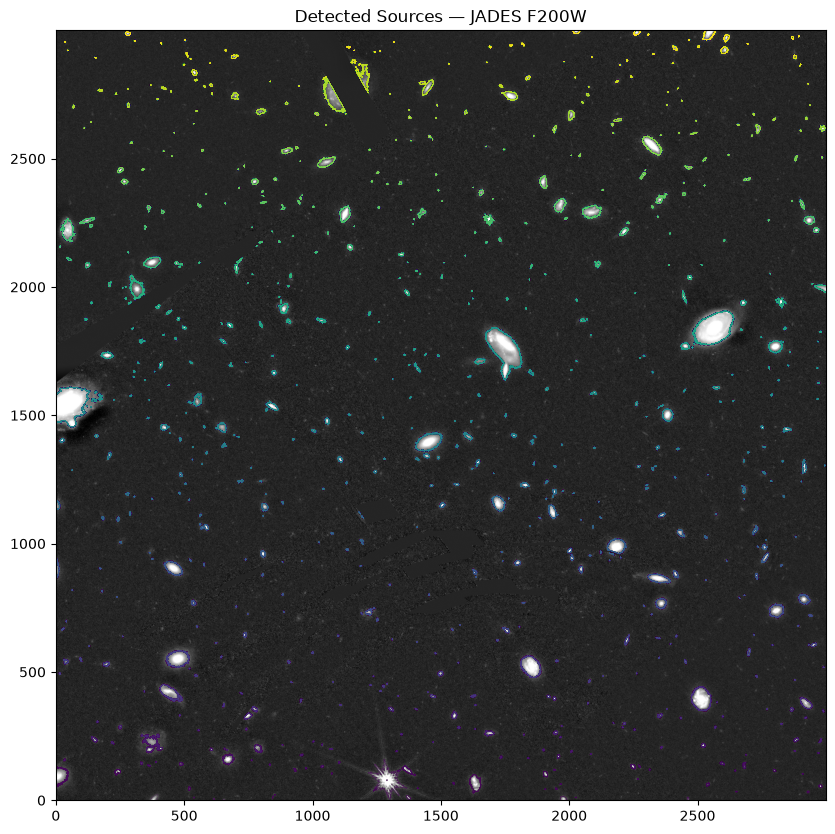

In [17]:
plt.figure(figsize=(10, 10))

plt.imshow(
    data_sub,
    origin="lower",
    cmap="gray",
    norm=norm
)

plt.contour(
    segm.data,
    levels=np.arange(0.5, segm.nlabels + 0.5, 1),
    linewidths=0.2,
    alpha=0.5
)

plt.title("Detected Sources — JADES F200W")

plt.show()

In [21]:
fits.writeto(
    OUTPUT_DIR / "jades_f200w_segmentation_2sigma.fits",
    segm.data,
    overwrite=True
)

fits.writeto(
    OUTPUT_DIR / "jades_f200w_background_subtracted.fits",
    data_sub,
    overwrite=True
)

In [24]:
sigmas = [1.5, 2.0, 3.0, 5.0]

results = []
segmaps = {}

mask = ~np.isfinite(data_sub)

for sigma in sigmas:
    threshold = sigma * bkg.background_rms

    seg = detect_sources(
        data_sub,
        threshold,
        n_pixels=10,
        mask=mask
    )

    if seg is None:
        n_sources = 0
    else:
        n_sources = seg.nlabels
        segmaps[sigma] = seg

    results.append({
        "threshold_sigma": sigma,
        "detected_sources": n_sources
    })

results_df = pd.DataFrame(results)

results_df.to_csv(
    OUTPUT_DIR / "detection_threshold_results.csv",
    index=False
)

results_df



,threshold_sigma,detected_sources
0,1.5,5080
1,2.0,2207
2,3.0,1232
3,5.0,775


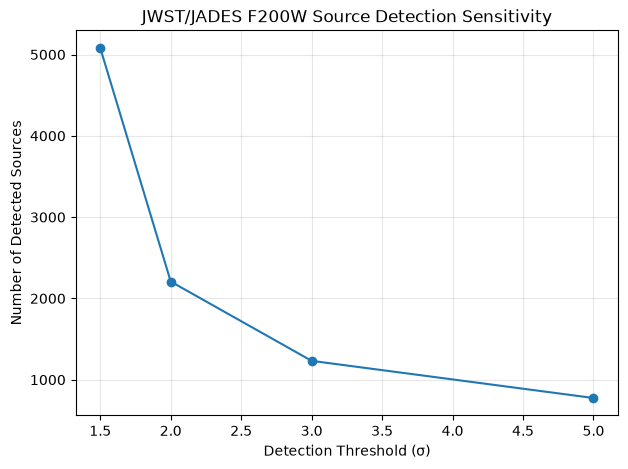

In [25]:
plt.figure(figsize=(7, 5))

plt.plot(
    results_df["threshold_sigma"],
    results_df["detected_sources"],
    marker="o"
)

plt.xlabel("Detection Threshold (σ)")
plt.ylabel("Number of Detected Sources")
plt.title("JWST/JADES F200W Source Detection Sensitivity")

plt.grid(alpha=0.3)
plt.show()


plt.savefig(
    OUTPUT_DIR / "detection_threshold_comparison.png",
    dpi=300,
    bbox_inches="tight"
)



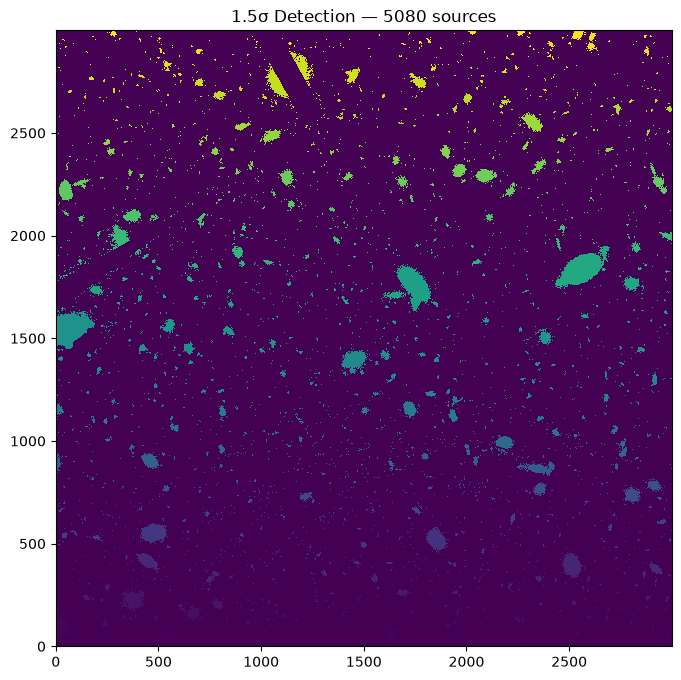

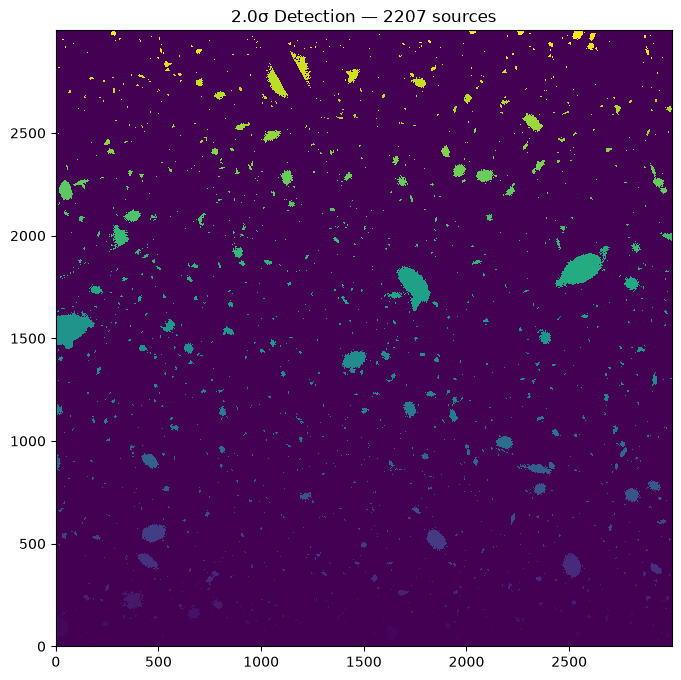

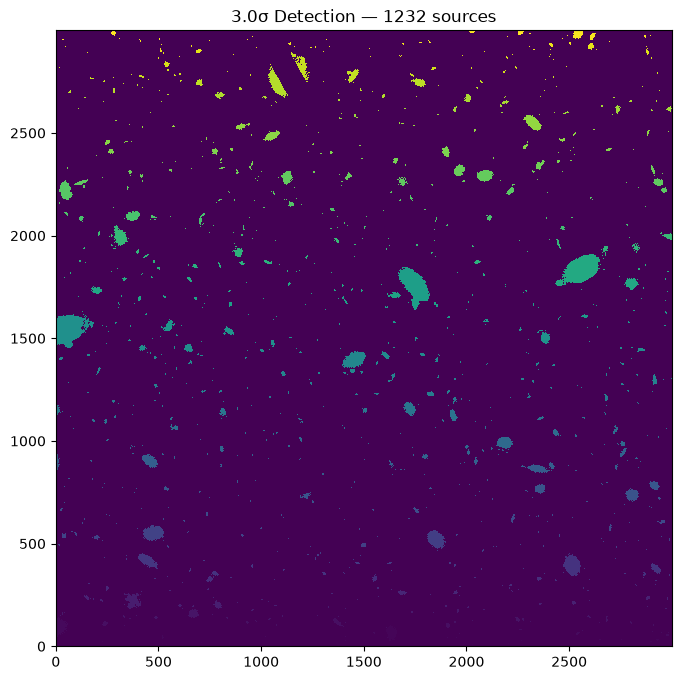

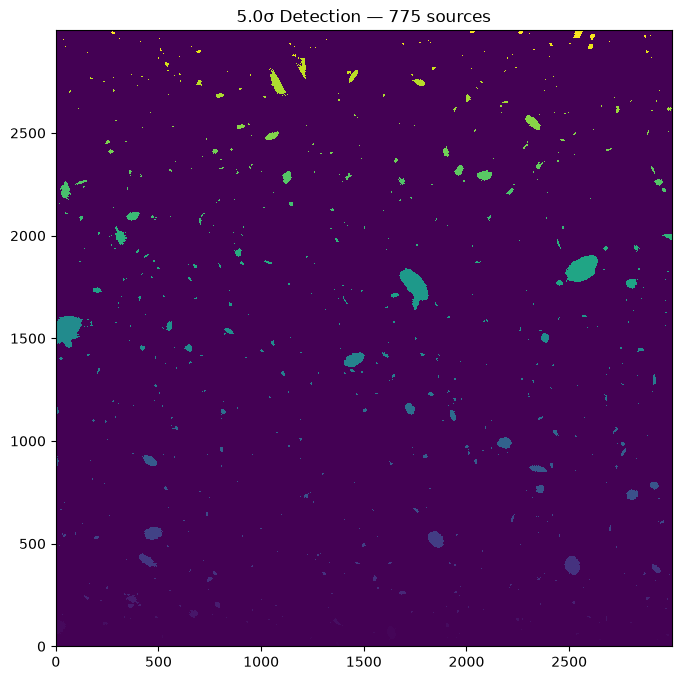

In [27]:
for sigma in sigmas:
    if sigma not in segmaps:
        continue

    plt.figure(figsize=(8, 8))

    plt.imshow(
        segmaps[sigma].data,
        origin="lower",
        interpolation="nearest"
    )

    plt.title(
        f"{sigma}σ Detection — "
        f"{segmaps[sigma].nlabels} sources"
    )

    plt.show()

In [28]:
from photutils.segmentation import SourceCatalog

segm_2sigma = segmaps[2.0]

catalog = SourceCatalog(
    data_sub,
    segm_2sigma,
    mask=mask
)

table = catalog.to_table(
    columns=[
        "label",
        "x_centroid",
        "y_centroid",
        "area",
        "segment_flux"
    ]
)

table[:20]

label,x_centroid,y_centroid,area,segment_flux
,,,pix2,
int32,float64,float64,float64,float64
1,383.7982690276218,7.685441109972273,729.0,33.84149276372045
2,615.6102504958131,4.775204229918191,55.0,1.4592929501086473
3,655.0290254885698,2.095434301341133,62.0,1.5536123281344771
4,747.5696295085112,0.7225430675140029,14.0,0.18758604861795902
5,1291.4777554091058,78.45437184495363,12177.0,3669.3790668956935
6,1977.9598054995763,5.73067530227546,581.0,29.481973594985902
7,2463.2919765427405,4.896285434717943,137.0,4.293928185477853
8,1373.4026778405655,11.061599493162317,282.0,13.46452226024121


In [31]:
catalog_df = table.to_pandas()

catalog_df = catalog_df.sort_values(
    "segment_flux",
    ascending=False
)

catalog_df.head(20)

catalog_df.to_csv(
    OUTPUT_DIR / "jades_f200w_source_catalog_2sigma.csv",
    index=False
)

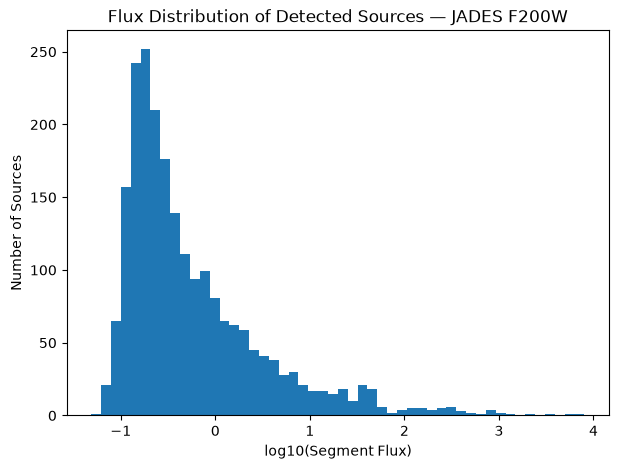

<Figure size 640x480 with 0 Axes>

In [34]:
flux = catalog_df["segment_flux"].values

flux = flux[np.isfinite(flux)]
flux = flux[flux > 0]

plt.figure(figsize=(7, 5))

plt.hist(
    np.log10(flux),
    bins=50
)

plt.xlabel("log10(Segment Flux)")
plt.ylabel("Number of Sources")
plt.title("Flux Distribution of Detected Sources — JADES F200W")

plt.show()

plt.savefig(
    OUTPUT_DIR / "f200w_flux_distribution.png",
    dpi=300,
    bbox_inches="tight"
)


## injection–recovery test

In [36]:
rng = np.random.default_rng(42)

base_seg = segmaps[2.0].data
mask = ~np.isfinite(data_sub)

def choose_blank_positions(n=100, margin=20, blank_radius=7, min_sep=20):
    ny, nx = data_sub.shape
    positions = []
    attempts = 0

    while len(positions) < n and attempts < 100000:
        attempts += 1

        x = int(rng.integers(margin, nx - margin))
        y = int(rng.integers(margin, ny - margin))

        ys = slice(y - blank_radius, y + blank_radius + 1)
        xs = slice(x - blank_radius, x + blank_radius + 1)

    
        if np.any(~np.isfinite(data_sub[ys, xs])):
            continue

    
        if np.any(base_seg[ys, xs] != 0):
            continue

    
        too_close = False
        for x0, y0 in positions:
            if (x - x0)**2 + (y - y0)**2 < min_sep**2:
                too_close = True
                break

        if too_close:
            continue

        positions.append((x, y))

    return positions


positions = choose_blank_positions(100)

print("Injection positions:", len(positions))

Injection positions: 100


In [37]:
fwhm = 3.0
gauss_sigma = fwhm / 2.355
half_size = 8

yy, xx = np.mgrid[
    -half_size:half_size + 1,
    -half_size:half_size + 1
]

gaussian_template = np.exp(
    -(xx**2 + yy**2) / (2 * gauss_sigma**2)
)

In [38]:
strengths = [3, 4, 5, 6, 8, 10, 15]


In [39]:
from photutils.segmentation import detect_sources

strengths = [3, 4, 5, 6, 8, 10, 15]

recovery_results = []

threshold = 2.0 * bkg.background_rms

for strength in strengths:

    injected_image = data_sub.copy()

    # -------------------------
    # Inject artificial sources
    # -------------------------

    for x, y in positions:

        local_rms = bkg.background_rms[y, x]

        amplitude = strength * local_rms

        stamp = amplitude * gaussian_template

        ys = slice(y - half_size, y + half_size + 1)
        xs = slice(x - half_size, x + half_size + 1)

        injected_image[ys, xs] += stamp

    # -------------------------
    # Run exactly the same
    # source detection
    # -------------------------

    injected_seg = detect_sources(
        injected_image,
        threshold,
        n_pixels=10,
        mask=mask
    )

    # -------------------------
    # Check which injected
    # sources were recovered
    # -------------------------

    recovered = 0

    if injected_seg is not None:

        segdata = injected_seg.data

        for x, y in positions:

            search_radius = 3

            ys = slice(
                y - search_radius,
                y + search_radius + 1
            )

            xs = slice(
                x - search_radius,
                x + search_radius + 1
            )

            if np.any(segdata[ys, xs] > 0):
                recovered += 1

    recovery_fraction = recovered / len(positions)

    recovery_results.append({
        "peak_sigma": strength,
        "injected": len(positions),
        "recovered": recovered,
        "recovery_fraction": recovery_fraction
    })

    print(
        f"{strength:>2}σ  "
        f"recovered {recovered}/{len(positions)}  "
        f"({100 * recovery_fraction:.1f}%)"
    )

 3σ  recovered 12/100  (12.0%)
 4σ  recovered 36/100  (36.0%)
 5σ  recovered 62/100  (62.0%)
 6σ  recovered 84/100  (84.0%)
 8σ  recovered 100/100  (100.0%)
10σ  recovered 100/100  (100.0%)
15σ  recovered 100/100  (100.0%)


In [40]:
recovery_df = pd.DataFrame(recovery_results)

recovery_df

,peak_sigma,injected,recovered,recovery_fraction
0,3,100,12,0.12
1,4,100,36,0.36
2,5,100,62,0.62
3,6,100,84,0.84
4,8,100,100,1.00
5,10,100,100,1.00
6,15,100,100,1.00


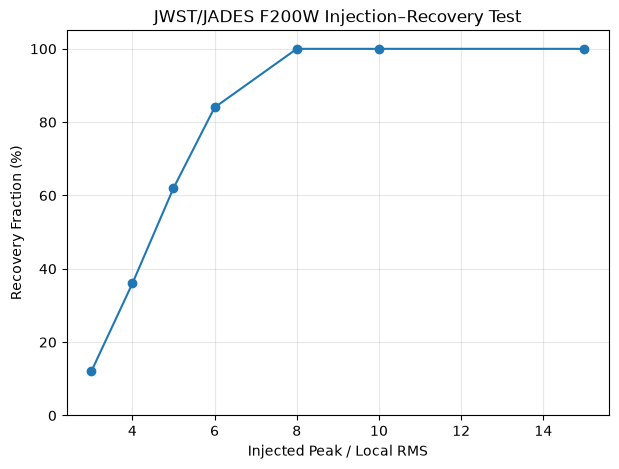

In [41]:
plt.figure(figsize=(7, 5))

plt.plot(
    recovery_df["peak_sigma"],
    recovery_df["recovery_fraction"] * 100,
    marker="o"
)

plt.xlabel("Injected Peak / Local RMS")
plt.ylabel("Recovery Fraction (%)")
plt.title("JWST/JADES F200W Injection–Recovery Test")

plt.ylim(0, 105)
plt.grid(alpha=0.3)

plt.savefig(
    OUTPUT_DIR / "f200w_injection_recovery.png",
    dpi=300,
    bbox_inches="tight"
)

plt.show()

recovery_df.to_csv(
    OUTPUT_DIR / "f200w_injection_recovery.csv",
    index=False
)

## Extended-source injection with a PSF-convolved Sérsic model

In [42]:
import numpy as np
import matplotlib.pyplot as plt

from astropy.modeling.models import Sersic2D
from astropy.convolution import Gaussian2DKernel, convolve


# Define the size of the simulated galaxy stamp
stamp_size = 41
half_stamp = stamp_size // 2

y_stamp, x_stamp = np.mgrid[
    -half_stamp:half_stamp + 1,
    -half_stamp:half_stamp + 1
]


# Define a simple Sérsic galaxy model
sersic_model = Sersic2D(
    amplitude=1.0,
    r_eff=3.0,
    n=1.0,
    x_0=0.0,
    y_0=0.0,
    ellip=0.3,
    theta=np.deg2rad(30.0)
)


# Evaluate the model on the pixel grid
galaxy_stamp = sersic_model(x_stamp, y_stamp)


# Define an illustrative Gaussian PSF
psf_fwhm = 2.5
psf_sigma = psf_fwhm / 2.355

psf_kernel = Gaussian2DKernel(psf_sigma)


# Convolve the intrinsic galaxy profile with the PSF
galaxy_psf = convolve(
    galaxy_stamp,
    psf_kernel,
    boundary="extend",
    normalize_kernel=True
)


# Normalize the model so that its peak value is 1
galaxy_psf /= np.max(galaxy_psf)

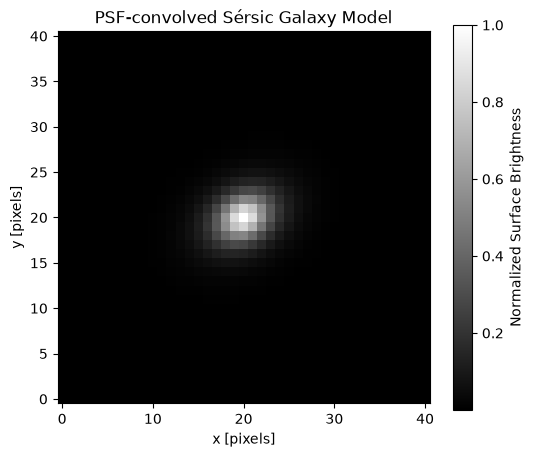

In [43]:
plt.figure(figsize=(6, 5))

plt.imshow(
    galaxy_psf,
    origin="lower",
    cmap="gray"
)

plt.colorbar(label="Normalized Surface Brightness")
plt.title("PSF-convolved Sérsic Galaxy Model")
plt.xlabel("x [pixels]")
plt.ylabel("y [pixels]")

plt.show()

In [44]:
rng = np.random.default_rng(42)

base_seg = segmaps[2.0].data
invalid_mask = ~np.isfinite(data_sub)


def choose_injection_positions(
    n_sources=50,
    margin=25,
    blank_radius=12,
    minimum_separation=35
):
    """Select blank positions for artificial-source injection."""

    ny, nx = data_sub.shape
    positions = []

    max_attempts = 100000
    attempts = 0

    while len(positions) < n_sources and attempts < max_attempts:
        attempts += 1

        x = int(rng.integers(margin, nx - margin))
        y = int(rng.integers(margin, ny - margin))

        y_slice = slice(
            y - blank_radius,
            y + blank_radius + 1
        )

        x_slice = slice(
            x - blank_radius,
            x + blank_radius + 1
        )

        # Reject regions containing invalid pixels
        if np.any(invalid_mask[y_slice, x_slice]):
            continue

        # Reject regions containing previously detected sources
        if np.any(base_seg[y_slice, x_slice] != 0):
            continue

        # Keep injected galaxies separated from each other
        if any(
            (x - x0) ** 2 + (y - y0) ** 2
            < minimum_separation ** 2
            for x0, y0 in positions
        ):
            continue

        positions.append((x, y))

    return positions


galaxy_positions = choose_injection_positions()

print(
    f"Selected {len(galaxy_positions)} "
    "blank positions for galaxy injection."
)

Selected 50 blank positions for galaxy injection.


In [45]:
from photutils.segmentation import detect_sources

peak_strengths = [2.5, 3, 4, 5, 6, 8, 10]

galaxy_recovery_results = []

detection_threshold = 2.0 * bkg.background_rms


for peak_sigma in peak_strengths:

    # Create an independent copy of the real JWST image
    injected_image = data_sub.copy()

    # Inject simulated galaxies into the image
    for x, y in galaxy_positions:

        local_rms = bkg.background_rms[y, x]

        # Scale the galaxy peak relative to the local noise
        peak_amplitude = peak_sigma * local_rms

        scaled_galaxy = galaxy_psf * peak_amplitude

        y_slice = slice(
            y - half_stamp,
            y + half_stamp + 1
        )

        x_slice = slice(
            x - half_stamp,
            x + half_stamp + 1
        )

        injected_image[y_slice, x_slice] += scaled_galaxy

    # Run the same source-detection pipeline
    injected_segmentation = detect_sources(
        injected_image,
        detection_threshold,
        n_pixels=10,
        mask=invalid_mask
    )

    recovered_sources = 0

    if injected_segmentation is not None:

        segmentation_data = injected_segmentation.data

        # Match detections to the known injection positions
        for x, y in galaxy_positions:

            matching_radius = 4

            y_slice = slice(
                y - matching_radius,
                y + matching_radius + 1
            )

            x_slice = slice(
                x - matching_radius,
                x + matching_radius + 1
            )

            if np.any(
                segmentation_data[y_slice, x_slice] > 0
            ):
                recovered_sources += 1

    recovery_fraction = (
        recovered_sources / len(galaxy_positions)
    )

    galaxy_recovery_results.append({
        "peak_sigma": peak_sigma,
        "injected_sources": len(galaxy_positions),
        "recovered_sources": recovered_sources,
        "recovery_fraction": recovery_fraction
    })

    print(
        f"Peak = {peak_sigma:>4.1f} sigma | "
        f"Recovered = {recovered_sources}/"
        f"{len(galaxy_positions)} | "
        f"Recovery = {100 * recovery_fraction:.1f}%"
    )

Peak =  2.5 sigma | Recovered = 16/50 | Recovery = 32.0%
Peak =  3.0 sigma | Recovered = 33/50 | Recovery = 66.0%
Peak =  4.0 sigma | Recovered = 50/50 | Recovery = 100.0%
Peak =  5.0 sigma | Recovered = 50/50 | Recovery = 100.0%
Peak =  6.0 sigma | Recovered = 50/50 | Recovery = 100.0%
Peak =  8.0 sigma | Recovered = 50/50 | Recovery = 100.0%
Peak = 10.0 sigma | Recovered = 50/50 | Recovery = 100.0%


In [46]:
galaxy_recovery_df = pd.DataFrame(
    galaxy_recovery_results
)
galaxy_recovery_df.to_csv(
    OUTPUT_DIR / "f200w_sersic_recovery_results.csv",
    index=False
)
galaxy_recovery_df

,peak_sigma,injected_sources,recovered_sources,recovery_fraction
0,2.5,50,16,0.32
1,3.0,50,33,0.66
2,4.0,50,50,1.00
3,5.0,50,50,1.00
4,6.0,50,50,1.00
5,8.0,50,50,1.00
6,10.0,50,50,1.00


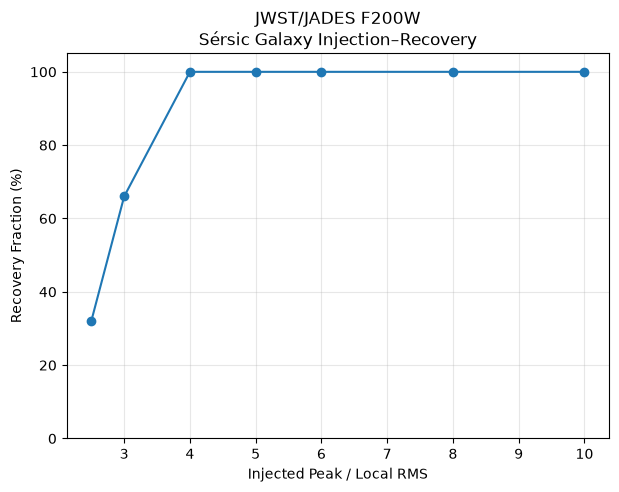

In [47]:
plt.figure(figsize=(7, 5))

plt.plot(
    galaxy_recovery_df["peak_sigma"],
    galaxy_recovery_df["recovery_fraction"] * 100,
    marker="o"
)

plt.xlabel("Injected Peak / Local RMS")
plt.ylabel("Recovery Fraction (%)")

plt.title(
    "JWST/JADES F200W\n"
    "Sérsic Galaxy Injection–Recovery"
)

plt.ylim(0, 105)
plt.grid(alpha=0.3)

plt.savefig(
    OUTPUT_DIR / "f200w_sersic_recovery_curve.png",
    dpi=300,
    bbox_inches="tight"
)

plt.show()

## Fixed-total-flux galaxy morphology experiment

In [48]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from astropy.modeling.models import Sersic2D
from astropy.convolution import Gaussian2DKernel, convolve
from photutils.segmentation import detect_sources, SourceCatalog

In [49]:
# Define a sufficiently large stamp to contain extended galaxy profiles
stamp_size = 101
half_stamp = stamp_size // 2

y_stamp, x_stamp = np.mgrid[
    -half_stamp:half_stamp + 1,
    -half_stamp:half_stamp + 1
]


# Use the same illustrative PSF for all galaxy models
psf_fwhm = 2.5
psf_sigma = psf_fwhm / 2.355
psf_kernel = Gaussian2DKernel(psf_sigma)


def create_normalized_sersic(
    r_eff,
    n=1.0,
    ellipticity=0.3,
    theta_deg=30.0
):
    """
    Create a PSF-convolved Sérsic galaxy model normalized
    to unit total flux.

    Parameters
    ----------
    r_eff : float
        Effective radius in pixels.
    n : float
        Sérsic index.
    ellipticity : float
        Galaxy ellipticity.
    theta_deg : float
        Position angle in degrees.

    Returns
    -------
    galaxy : ndarray
        PSF-convolved galaxy stamp with total pixel sum = 1.
    """

    model = Sersic2D(
        amplitude=1.0,
        r_eff=r_eff,
        n=n,
        x_0=0.0,
        y_0=0.0,
        ellip=ellipticity,
        theta=np.deg2rad(theta_deg)
    )

    galaxy = model(x_stamp, y_stamp)

    # Convolve the intrinsic galaxy profile with the PSF
    galaxy = convolve(
        galaxy,
        psf_kernel,
        boundary="extend",
        normalize_kernel=True
    )

    # Remove any small numerical negative values
    galaxy = np.clip(galaxy, 0, None)

    # Normalize to unit total flux
    galaxy /= np.sum(galaxy)

    return galaxy

In [50]:
r_eff_values = [1.5, 3.0, 5.0, 8.0]

galaxy_models = {}

for r_eff in r_eff_values:
    galaxy_models[r_eff] = create_normalized_sersic(r_eff)

    print(
        f"r_eff = {r_eff:>4.1f} pixels | "
        f"total = {galaxy_models[r_eff].sum():.4f} | "
        f"peak = {galaxy_models[r_eff].max():.6f}"
    )

r_eff =  1.5 pixels | total = 1.0000 | peak = 0.074089
r_eff =  3.0 pixels | total = 1.0000 | peak = 0.033148
r_eff =  5.0 pixels | total = 1.0000 | peak = 0.015765
r_eff =  8.0 pixels | total = 1.0000 | peak = 0.007311


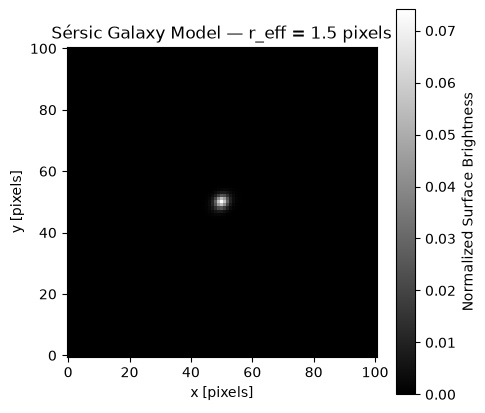

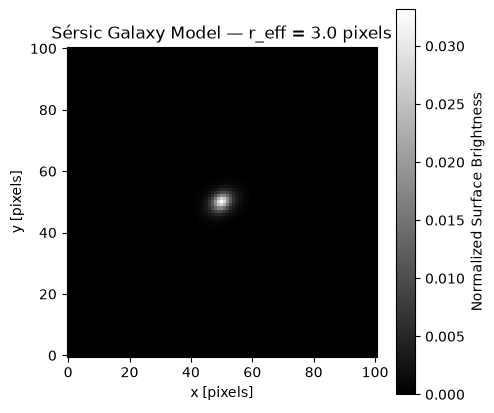

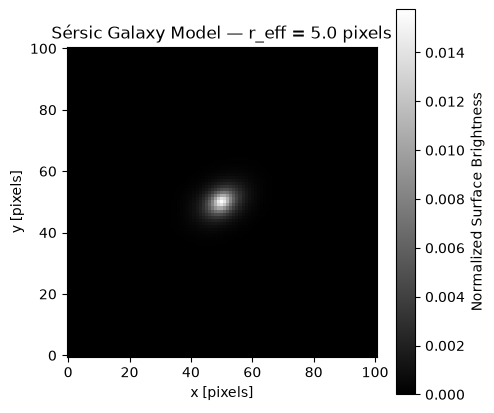

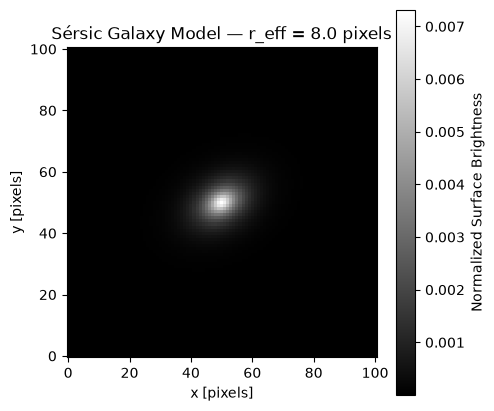

In [51]:
display_total_flux = 1.0

for r_eff in r_eff_values:

    plt.figure(figsize=(5, 5))

    plt.imshow(
        galaxy_models[r_eff] * display_total_flux,
        origin="lower",
        cmap="gray"
    )

    plt.colorbar(label="Normalized Surface Brightness")

    plt.title(
        f"Sérsic Galaxy Model — r_eff = {r_eff} pixels"
    )

    plt.xlabel("x [pixels]")
    plt.ylabel("y [pixels]")

    plt.show()

In [52]:
rng = np.random.default_rng(42)

base_segmentation = segmaps[2.0].data
invalid_mask = ~np.isfinite(data_sub)


def select_blank_positions(
    n_sources=50,
    margin=55,
    blank_radius=20,
    minimum_separation=110
):
    """
    Select isolated blank regions for artificial-galaxy injection.
    """

    ny, nx = data_sub.shape
    positions = []

    attempts = 0
    max_attempts = 200000

    while len(positions) < n_sources and attempts < max_attempts:
        attempts += 1

        x = int(rng.integers(margin, nx - margin))
        y = int(rng.integers(margin, ny - margin))

        y_slice = slice(
            y - blank_radius,
            y + blank_radius + 1
        )

        x_slice = slice(
            x - blank_radius,
            x + blank_radius + 1
        )

        # Reject invalid regions
        if np.any(invalid_mask[y_slice, x_slice]):
            continue

        # Reject regions containing existing detected sources
        if np.any(
            base_segmentation[y_slice, x_slice] != 0
        ):
            continue

        # Keep artificial galaxies well separated
        too_close = any(
            (x - x0) ** 2 + (y - y0) ** 2
            < minimum_separation ** 2
            for x0, y0 in positions
        )

        if too_close:
            continue

        positions.append((x, y))

    return positions


morphology_positions = select_blank_positions()

print(
    f"Selected {len(morphology_positions)} "
    "injection positions."
)

Selected 50 injection positions.


In [54]:
flux_scales = [30, 50, 80, 120, 200, 320]
detection_threshold = 2.0 * bkg.background_rms

morphology_results = []


for r_eff in r_eff_values:

    galaxy_template = galaxy_models[r_eff]

    for flux_scale in flux_scales:

        # Start from an independent copy of the real JWST image
        injected_image = data_sub.copy()

        # Inject galaxies with the same noise-scaled total flux
        for x, y in morphology_positions:

            local_rms = bkg.background_rms[y, x]

            total_flux = flux_scale * local_rms

            artificial_galaxy = (
                galaxy_template * total_flux
            )

            y_slice = slice(
                y - half_stamp,
                y + half_stamp + 1
            )

            x_slice = slice(
                x - half_stamp,
                x + half_stamp + 1
            )

            injected_image[
                y_slice,
                x_slice
            ] += artificial_galaxy

        # Run the same segmentation-based source detector
        segmentation = detect_sources(
            injected_image,
            detection_threshold,
            n_pixels=10,
            mask=invalid_mask
        )

        recovered = 0

        if segmentation is not None:

            # Build a catalog of all detected sources
            detection_catalog = SourceCatalog(
                injected_image,
                segmentation,
                mask=invalid_mask
            )

            detection_table = detection_catalog.to_table(
                columns=[
                    "x_centroid",
                    "y_centroid"
                ]
            )

            detected_x = np.asarray(
                detection_table["x_centroid"],
                dtype=float
            )

            detected_y = np.asarray(
                detection_table["y_centroid"],
                dtype=float
            )

            # Match detections to known injection coordinates
            matching_radius = 4.0

            for x_inj, y_inj in morphology_positions:

                distances = np.sqrt(
                    (detected_x - x_inj) ** 2
                    +
                    (detected_y - y_inj) ** 2
                )

                if np.any(distances <= matching_radius):
                    recovered += 1

        recovery_fraction = (
            recovered / len(morphology_positions)
        )

        morphology_results.append({
            "r_eff_pixels": r_eff,
            "flux_scale": flux_scale,
            "injected_sources": len(morphology_positions),
            "recovered_sources": recovered,
            "recovery_fraction": recovery_fraction
        })

        print(
            f"r_eff = {r_eff:>4.1f} px | "
            f"flux scale = {flux_scale:>3} | "
            f"recovered = {recovered:>2}/"
            f"{len(morphology_positions)} | "
            f"{100 * recovery_fraction:>5.1f}%"
        )

r_eff =  1.5 px | flux scale =  30 | recovered =  0/50 |   0.0%
r_eff =  1.5 px | flux scale =  50 | recovered = 24/50 |  48.0%
r_eff =  1.5 px | flux scale =  80 | recovered = 48/50 |  96.0%
r_eff =  1.5 px | flux scale = 120 | recovered = 50/50 | 100.0%
r_eff =  1.5 px | flux scale = 200 | recovered = 50/50 | 100.0%
r_eff =  1.5 px | flux scale = 320 | recovered = 50/50 | 100.0%
r_eff =  3.0 px | flux scale =  30 | recovered =  0/50 |   0.0%
r_eff =  3.0 px | flux scale =  50 | recovered =  0/50 |   0.0%
r_eff =  3.0 px | flux scale =  80 | recovered = 27/50 |  54.0%
r_eff =  3.0 px | flux scale = 120 | recovered = 48/50 |  96.0%
r_eff =  3.0 px | flux scale = 200 | recovered = 50/50 | 100.0%
r_eff =  3.0 px | flux scale = 320 | recovered = 50/50 | 100.0%
r_eff =  5.0 px | flux scale =  30 | recovered =  0/50 |   0.0%
r_eff =  5.0 px | flux scale =  50 | recovered =  0/50 |   0.0%
r_eff =  5.0 px | flux scale =  80 | recovered =  1/50 |   2.0%
r_eff =  5.0 px | flux scale = 120 | rec

In [55]:
morphology_df = pd.DataFrame(
    morphology_results
)
morphology_df.to_csv(
    OUTPUT_DIR / "f200w_morphology_completeness.csv",
    index=False
)
morphology_df

,r_eff_pixels,flux_scale,injected_sources,recovered_sources,recovery_fraction
0,1.5,30,50,0,0.00
1,1.5,50,50,24,0.48
2,1.5,80,50,48,0.96
3,1.5,120,50,50,1.00
4,1.5,200,50,50,1.00
5,1.5,320,50,50,1.00
6,3.0,30,50,0,0.00
7,3.0,50,50,0,0.00
8,3.0,80,50,27,0.54
9,3.0,120,50,48,0.96


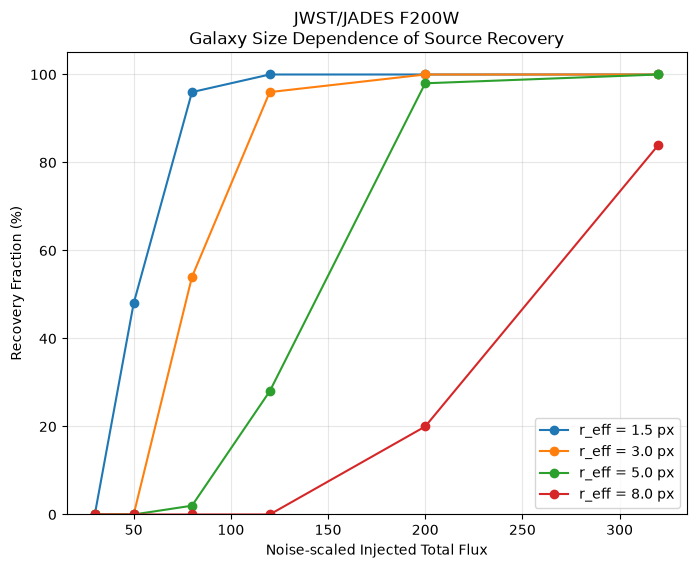

In [56]:
plt.figure(figsize=(8, 6))

for r_eff in r_eff_values:

    subset = morphology_df[
        morphology_df["r_eff_pixels"] == r_eff
    ]

    plt.plot(
        subset["flux_scale"],
        subset["recovery_fraction"] * 100,
        marker="o",
        label=f"r_eff = {r_eff} px"
    )

plt.xlabel("Noise-scaled Injected Total Flux")
plt.ylabel("Recovery Fraction (%)")

plt.title(
    "JWST/JADES F200W\n"
    "Galaxy Size Dependence of Source Recovery"
)

plt.ylim(0, 105)
plt.grid(alpha=0.3)
plt.legend()

plt.savefig(
    OUTPUT_DIR / "f200w_morphology_recovery.png",
    dpi=300,
    bbox_inches="tight"
)

plt.show()